# Accepted Code Object Mining Report

This notebook profiles `dataset/accepted_codeobject_mining_raw.jsonl` and generates a compact EDA report for the accepted repair traces.

In [41]:
import json
import os
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 140)

def find_repo_root() -> Path:
    env_root = os.getenv('PROJECT_ROOT_DIR')
    if env_root:
        env_path = Path(env_root).resolve()
        if (env_path / 'dataset' / 'accepted_codeobject_mining_raw.jsonl').exists():
            return env_path

    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'dataset' / 'accepted_codeobject_mining_raw.jsonl').exists():
            return candidate

    raise FileNotFoundError('Could not locate dataset/accepted_codeobject_mining_raw.jsonl from the current environment.')


REPO_ROOT = find_repo_root()
DATASET_PATH = REPO_ROOT / 'dataset' / 'accepted_codeobject_mining_raw.jsonl'
REPORT_DIR = REPO_ROOT / 'results' / 'accepted_codeobject_mining_report'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print('Repository root:', REPO_ROOT)
print('Dataset path:', DATASET_PATH)
print('Report directory:', REPORT_DIR)

Repository root: /home/diogenes/pylingual_colaboration/pylingual_download/code
Dataset path: /home/diogenes/pylingual_colaboration/pylingual_download/code/dataset/accepted_codeobject_mining_raw.jsonl
Report directory: /home/diogenes/pylingual_colaboration/pylingual_download/code/results/accepted_codeobject_mining_report


In [42]:
def load_jsonl(path: Path) -> pd.DataFrame:
    with path.open('r', encoding='utf-8') as f:
        rows = [json.loads(line) for line in f]
    return pd.DataFrame(rows)


def safe_len(value) -> int:
    return len(value) if isinstance(value, str) else 0


def plot_hist_with_normal(
    ax,
    values,
    *,
    bins=30,
    color='#4C78A8',
    title='',
    xlabel='',
    focus_quantiles=(0.01, 0.99),
    focus_min=None,
    focus_max=None,
):
    series = pd.Series(values).dropna().astype(float)
    if series.empty:
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        return

    lo = series.quantile(focus_quantiles[0]) if focus_min is None else focus_min
    hi = series.quantile(focus_quantiles[1]) if focus_max is None else focus_max
    focused = series[(series >= lo) & (series <= hi)]
    if focused.empty:
        focused = series

    mu = focused.mean()
    sigma = focused.std(ddof=0)
    if sigma == 0 or math.isnan(sigma):
        sigma = 1e-9

    ax.hist(focused, bins=bins, density=True, color=color, alpha=0.72, edgecolor='white')
    x_min = focused.min()
    x_max = focused.max()
    if x_min == x_max:
        x_min -= 1
        x_max += 1
    x = np.linspace(x_min, x_max, 400)
    y = (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    ax.plot(x, y, color='black', linewidth=2)
    ax.axvline(mu, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{title} (normal fit)')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.set_xlim(x_min, x_max)


def flatten_row(row: pd.Series) -> pd.Series:
    prompt = row['prompt'] if isinstance(row.get('prompt'), dict) else {}
    target_before = row.get('target_score_before') if isinstance(row.get('target_score_before'), dict) else {}
    target_after = row.get('target_score_after') if isinstance(row.get('target_score_after'), dict) else {}
    bytecode_context = row.get('bytecode_context') if isinstance(row.get('bytecode_context'), dict) else {}
    usage = prompt.get('usage') if isinstance(prompt.get('usage'), dict) else {}

    return pd.Series({
        'system_prompt': prompt.get('system_prompt'),
        'user_prompt': prompt.get('user_prompt'),
        'assistant_response': prompt.get('response_text'),
        'prompt_provider': prompt.get('provider'),
        'prompt_model': prompt.get('model'),
        'prompt_variant': prompt.get('prompt_variant'),
        'prompt_path': prompt.get('prompt_path'),
        'prompt_latency_ms': prompt.get('latency_ms'),
        'prompt_total_tokens': usage.get('total_tokens'),
        'messages_len': len(prompt.get('messages') or []),
        'system_len': safe_len(prompt.get('system_prompt')),
        'user_len': safe_len(prompt.get('user_prompt')),
        'assistant_len': safe_len(prompt.get('response_text')),
        'extracted_before_len': safe_len(row.get('extracted_before')),
        'replacement_text_len': safe_len(row.get('replacement_text')),
        'combined_distance_before': (target_before or {}).get('combined_distance'),
        'combined_distance_after': (target_after or {}).get('combined_distance'),
        'combined_distance_delta': row.get('combined_distance_delta'),
        'bytecode_alignment_tag': bytecode_context.get('alignment_tag'),
        'gt_instruction_range': bytecode_context.get('gt_instruction_range'),
        'derived_instruction_range': bytecode_context.get('derived_instruction_range'),
    })


df = load_jsonl(DATASET_PATH)
flat = pd.concat([df, df.apply(flatten_row, axis=1).add_prefix('flat_')], axis=1)
accepted = flat[flat['accepted'] == True].copy()

print('Raw rows:', len(df))
print('Accepted rows:', len(accepted))
display(accepted.head(3))

Raw rows: 1903
Accepted rows: 1903


,run_id,timestamp,source_file_hash,qualname,repair_operation,iteration,step,accepted,acceptance_reason,target_kind,...,flat_user_len,flat_assistant_len,flat_extracted_before_len,flat_replacement_text_len,flat_combined_distance_before,flat_combined_distance_after,flat_combined_distance_delta,flat_bytecode_alignment_tag,flat_gt_instruction_range,flat_derived_instruction_range
0,76640a505d324fda91b2992022932082,2026-05-01T06:37:29+00:00,81276beb85275067b3215ede9efca171fc6bb09974dc477b6579df9e38c4f582,<module>.calculate_severirty,repair_source_fragment,4,7,True,combined distance improved,code_object_fragment,...,3236.0,785.0,804.0,785.0,231.0,183.0,-48.0,delete,NaN,NaN
1,76640a505d324fda91b2992022932082,2026-05-01T06:44:34+00:00,5d5345f4be25a22923dd924ec0c5ed39dc615232fb6d7199642faf888c5a1ae3,<module>.PyiFrozenEntryPointLoader.get_code,repair_source_fragment,1,1,True,combined distance improved,code_object_fragment,...,2554.0,191.0,191.0,203.0,5.0,0.0,-5.0,replace,NaN,NaN
2,76640a505d324fda91b2992022932082,2026-05-01T06:44:36+00:00,5d5345f4be25a22923dd924ec0c5ed39dc615232fb6d7199642faf888c5a1ae3,<module>.PyiFrozenImporter.exec_module,repair_source_fragment,1,2,True,combined distance improved,code_object_fragment,...,3117.0,779.0,777.0,835.0,1.0,0.0,-1.0,replace,NaN,NaN


In [43]:
summary = pd.DataFrame([
    {'metric': 'rows', 'value': len(accepted)},
    {'metric': 'rows_with_prompt', 'value': int(accepted['prompt'].notna().sum())},
    {'metric': 'rows_without_prompt', 'value': int(accepted['prompt'].isna().sum())},
    {'metric': 'accepted_rate', 'value': round(len(accepted) / len(df), 4)},
    {'metric': 'prompt_coverage', 'value': round(accepted['prompt'].notna().mean(), 4)},
    {'metric': 'unique_run_id', 'value': accepted['run_id'].nunique()},
    {'metric': 'unique_source_file_hash', 'value': accepted['source_file_hash'].nunique()},
])

display(summary)

composition = pd.DataFrame({
    'target_kind': accepted['target_kind'].value_counts(dropna=False),
    'source_kind': accepted['source_kind'].value_counts(dropna=False),
    'repair_operation': accepted['repair_operation'].value_counts(dropna=False),
}).fillna(0).astype(int)

display(composition)

qualname_counts = accepted['qualname'].value_counts().head(20).reset_index()
qualname_counts.columns = ['qualname', 'count']
display(qualname_counts)


,metric,value
0,rows,1903.0000
1,rows_with_prompt,1902.0000
2,rows_without_prompt,1.0000
3,accepted_rate,1.0000
4,prompt_coverage,0.9995
5,unique_run_id,5.0000
6,unique_source_file_hash,826.0000


,target_kind,source_kind,repair_operation
async_function,0,99,0
class,0,89,0
code_object_fragment,1870,0,0
delete_extra,0,0,1
dictcomp,0,2,0
function,0,1673,0
genexpr,0,1,0
lambda,0,3,0
listcomp,0,4,0
module_statement,32,0,0


,qualname,count
0,<module>.main,36
1,<module>,32
2,<module>.PyiFrozenImporter.find_spec,24
3,<module>.ZlibArchiveReader.extract,16
4,<module>.PyiFrozenImporter.path_hook,15
5,<module>.write_prompt_detail_to_csv,13
6,<module>.insert_metadata_pyexiv2,11
7,<module>.PyiFrozenImporter.get_code,10
8,<module>.PyiFrozenImporter.get_filename,10
9,<module>.Aimbot.is_target_locked,10


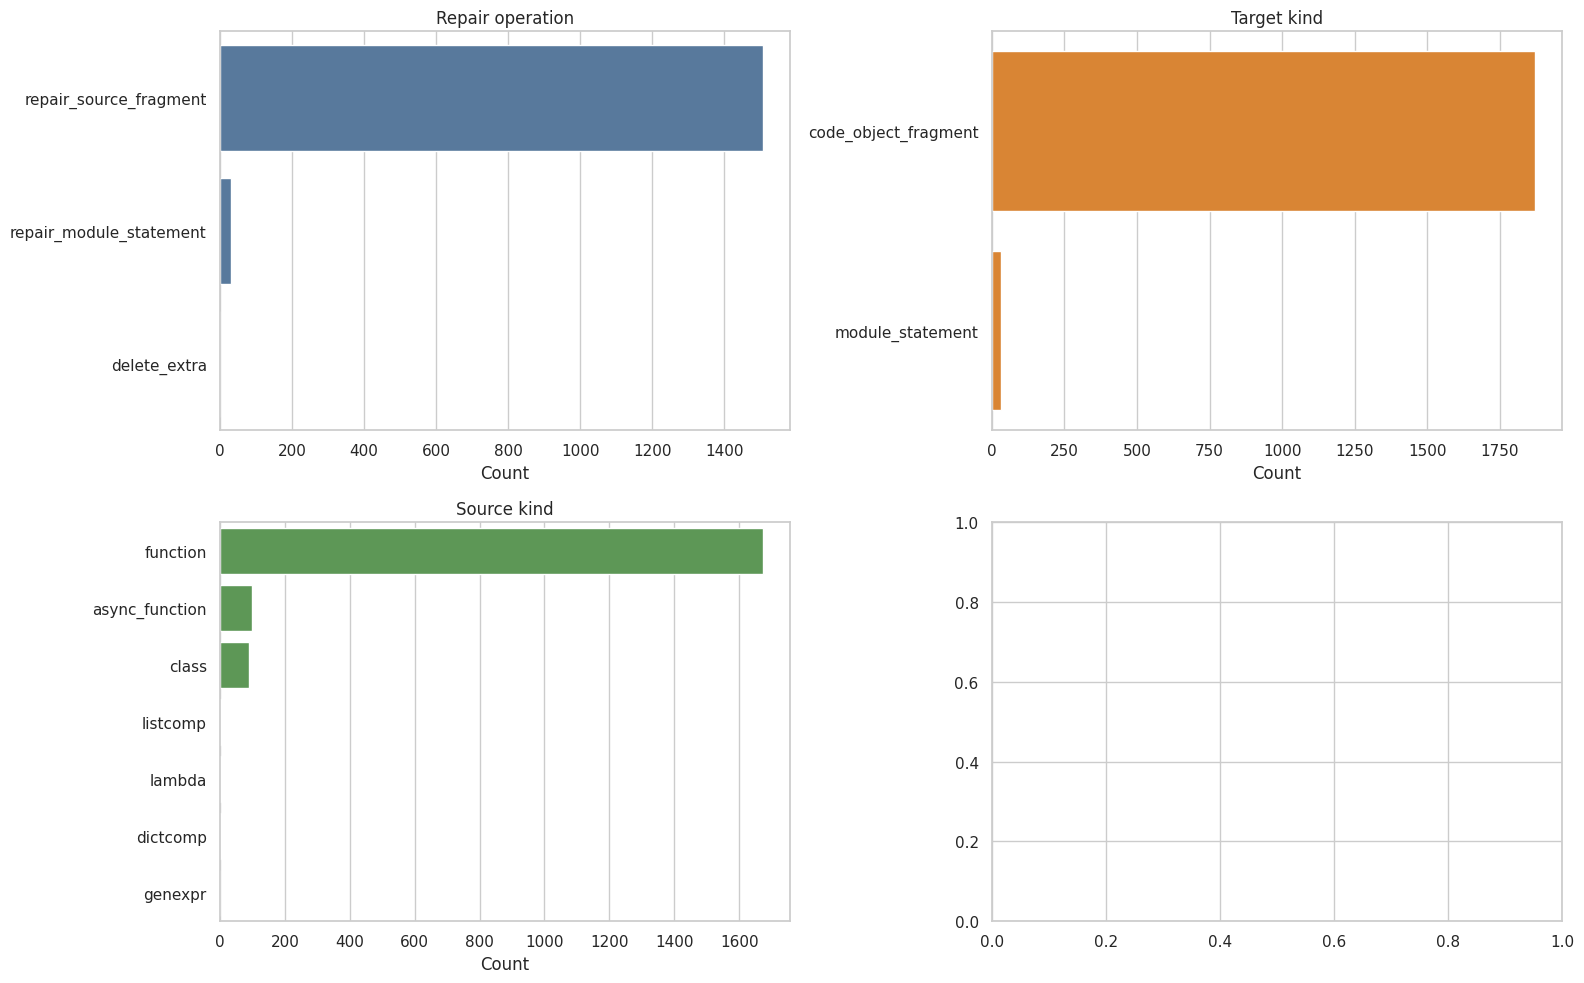

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(data=accepted, y='repair_operation', order=accepted['repair_operation'].value_counts().index, ax=axes[0, 0], color='#4C78A8')
axes[0, 0].set_title('Repair operation')
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_ylabel('')

sns.countplot(data=accepted, y='target_kind', order=accepted['target_kind'].value_counts().index, ax=axes[0, 1], color='#F58518')
axes[0, 1].set_title('Target kind')
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_ylabel('')

sns.countplot(data=accepted, y='source_kind', order=accepted['source_kind'].value_counts().index, ax=axes[1, 0], color='#54A24B')
axes[1, 0].set_title('Source kind')
axes[1, 0].set_xlabel('Count')
axes[1, 0].set_ylabel('')


plt.tight_layout()
plt.show()


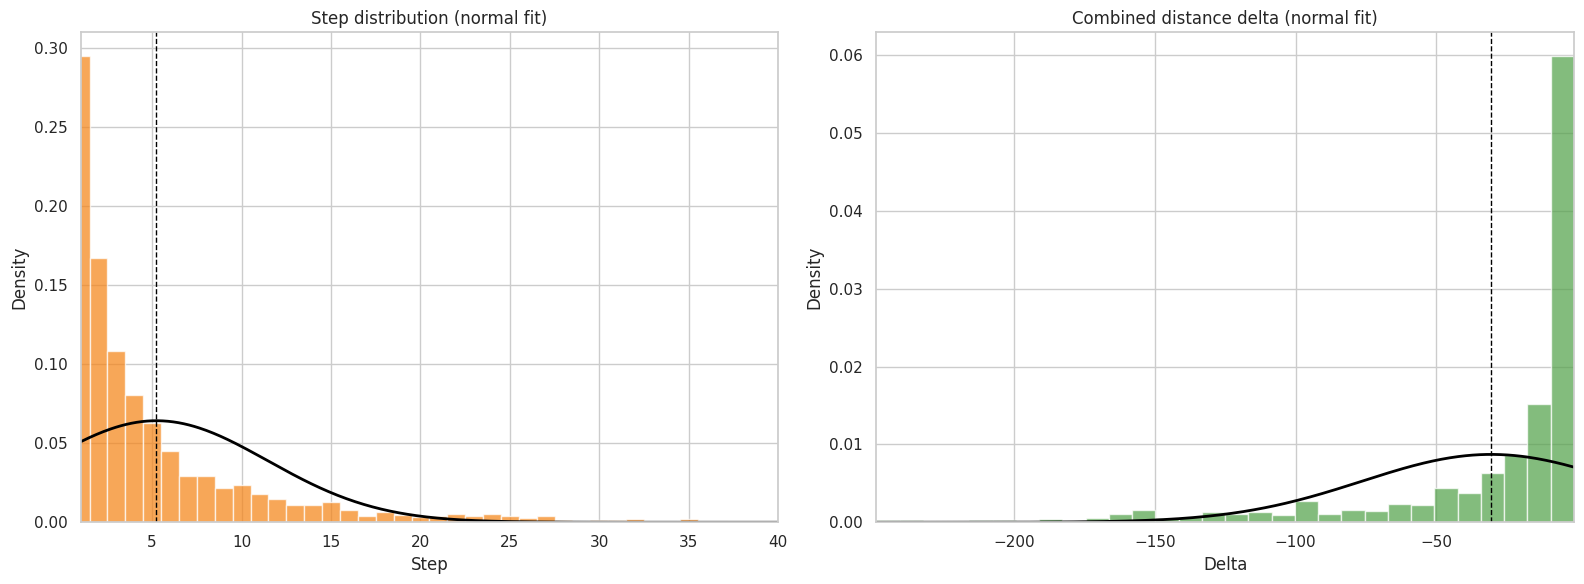

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_hist_with_normal(
    axes[0],
    accepted['step'],
    bins=np.arange(0.5, 50.5, 1),
    color='#F58518',
    title='Step distribution',
    xlabel='Step',
    focus_max=40,
)

plot_hist_with_normal(
    axes[1],
    accepted['flat_combined_distance_delta'],
    bins=30,
    color='#54A24B',
    title='Combined distance delta',
    xlabel='Delta',
    focus_min=-250,
)

plt.tight_layout()
plt.show()


,count,mean,median,min,max
flat_system_len,1903.0,758.601156,759.0,0.0,759.0
flat_user_len,1903.0,5341.005780,3651.0,0.0,176992.0
flat_assistant_len,1903.0,1917.142932,904.0,0.0,174358.0
flat_extracted_before_len,1903.0,1733.074619,885.0,12.0,80472.0
flat_replacement_text_len,1903.0,1969.414083,945.0,0.0,174358.0


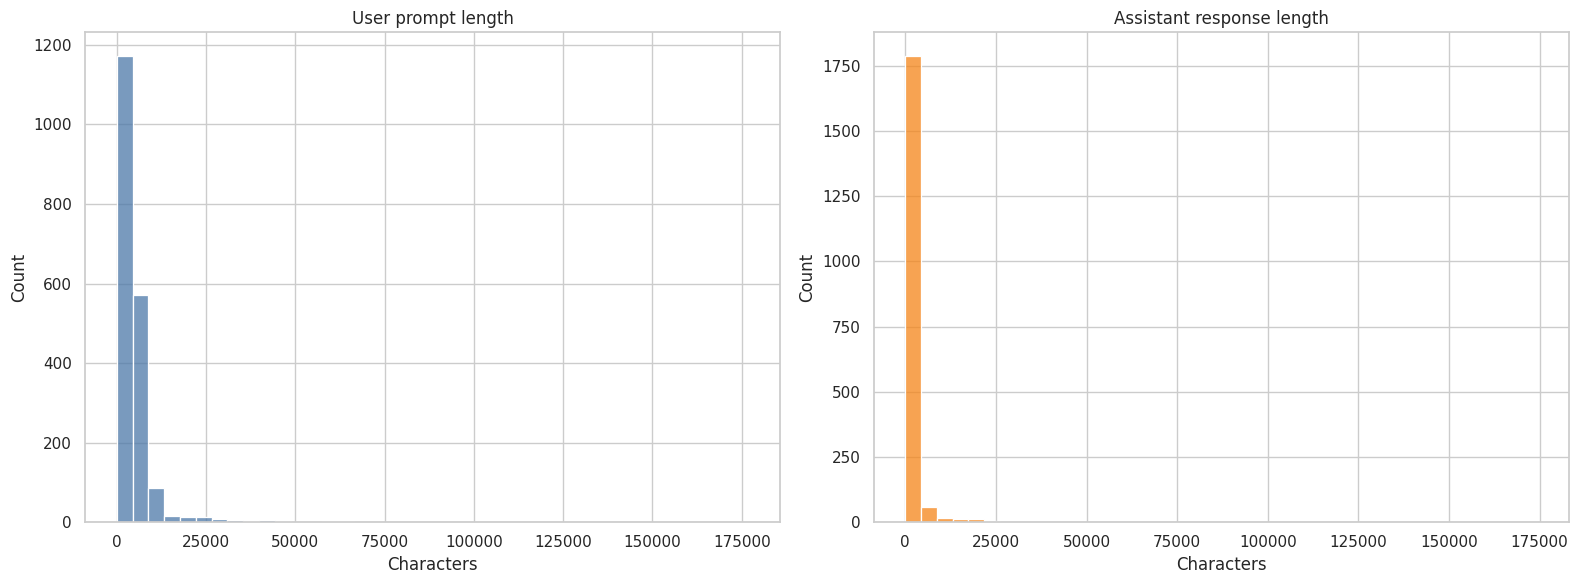

In [46]:
length_cols = ['flat_system_len', 'flat_user_len', 'flat_assistant_len', 'flat_extracted_before_len', 'flat_replacement_text_len']
length_summary = accepted[length_cols].describe().T[['count', 'mean', '50%', 'min', 'max']].rename(columns={'50%': 'median'})
display(length_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(accepted['flat_user_len'], bins=40, ax=axes[0], color='#4C78A8')
axes[0].set_title('User prompt length')
axes[0].set_xlabel('Characters')

sns.histplot(accepted['flat_assistant_len'], bins=40, ax=axes[1], color='#F58518')
axes[1].set_title('Assistant response length')
axes[1].set_xlabel('Characters')

plt.tight_layout()
plt.show()


In [47]:
top_qualnames = accepted['qualname'].value_counts().head(25).reset_index()
top_qualnames.columns = ['qualname', 'count']
display(top_qualnames)

provider_model = accepted.groupby(['flat_prompt_provider', 'flat_prompt_model']).size().reset_index(name='count')
display(provider_model.sort_values(['count', 'flat_prompt_model'], ascending=[False, True]))

accepted[['run_id', 'timestamp', 'qualname', 'repair_operation', 'target_kind', 'source_kind', 'iteration', 'step', 'flat_prompt_model', 'flat_combined_distance_delta']].to_csv(
    REPORT_DIR / 'accepted_codeobject_mining_summary.csv',
    index=False,
)

print('Saved summary tables and plots to:', REPORT_DIR)


,qualname,count
0,<module>.main,36
1,<module>,32
2,<module>.PyiFrozenImporter.find_spec,24
3,<module>.ZlibArchiveReader.extract,16
4,<module>.PyiFrozenImporter.path_hook,15
5,<module>.write_prompt_detail_to_csv,13
6,<module>.insert_metadata_pyexiv2,11
7,<module>.PyiFrozenImporter.get_code,10
8,<module>.PyiFrozenImporter.get_filename,10
9,<module>.Aimbot.is_target_locked,10


,flat_prompt_provider,flat_prompt_model,count
0,OpenAI,gpt-5.4-mini,1453
1,OpenAI,gpt-5.5-1,449


Saved summary tables and plots to: /home/diogenes/pylingual_colaboration/pylingual_download/code/results/accepted_codeobject_mining_report
